# 📦 Demand Forecasting & Inventory Optimization Engine
## Milestone 3 & 4: Inventory Optimization + MLOps Monitoring

---

**👥 Team Members:** Mark · Fady · Ahmed · Eman · Sama · Hadeer  
**📅 Date:** February 2026  
**🎯 Objective:**
- **Milestone 3:** Inventory recommendations (EOQ, Safety Stock, Reorder Point).
- **Milestone 4:** MLOps monitoring — data drift, model drift, retraining alerts.

---

### 📋 Table of Contents
1. [Setup & Data Loading](#1.-Setup-&-Data-Loading)
2. [Load Forecast Predictions](#2.-Load-Forecast-Predictions)
3. [Inventory Optimization — EOQ](#3.-Inventory-Optimization-EOQ)
4. [Safety Stock & Reorder Point](#4.-Safety-Stock-&-Reorder-Point)
5. [Inventory Simulation](#5.-Inventory-Simulation)
6. [MLOps — Data Drift (PSI)](#6.-MLOps-Data-Drift)
7. [MLOps — Model Performance Drift](#7.-MLOps-Model-Performance-Drift)
8. [Retraining Decision Logic](#8.-Retraining-Decision-Logic)
9. [Summary Report](#9.-Summary-Report)

---
## 1. Setup & Data Loading <a id='1.-Setup-&-Data-Loading'></a>

In [1]:
# ══════════════════════════════════════════════════════════════════════════════
# 1.1 Import Libraries
# ══════════════════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
import joblib
import json

warnings.filterwarnings('ignore')
np.random.seed(42)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False
})
COLORS = sns.color_palette('muted', 10)

print('✅ Libraries imported')

✅ Libraries imported


In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# 1.2 Load Data
# ══════════════════════════════════════════════════════════════════════════════
# Raw data for pricing and historical context
df_raw = pd.read_csv('weekly.csv', encoding='utf-8-sig')
df_raw.columns = [
    'Year', 'Week', 'ItemID', 'Qty', 'ItemName', 'BrandID', 'BrandName',
    'MasterBrandID', 'MasterBrandName', 'UOM', 'Factor',
    'Avg_Daily_Demand', 'Safety_Stock', 'ROP', 'Avg_UnitPrice',
    'Total_Promo', 'Total_CashDiscount', 'Total_ManualDiscount',
    'Total_Taxes', 'Total_Revenue'
]
df_raw['Qty'] = df_raw['Qty'].clip(lower=0)

# ML Forecasts from Milestone 2
PROC_DIR = Path('..') / 'data' / 'processed'
df_fc = pd.read_csv(PROC_DIR / 'ml_forecasts.csv', encoding='utf-8-sig')

# Get average unit price per SKU for EOQ calculations
sku_price = df_raw.groupby('ItemID')['Avg_UnitPrice'].mean().reset_index()
df_fc = df_fc.merge(sku_price, on='ItemID', how='left')

print(f'✅ ML Forecasts loaded: {df_fc.shape[0]} SKUs')
print(f'✅ Raw data loaded: {df_raw.shape[0]} rows')

✅ ML Forecasts loaded: 136 SKUs
✅ Raw data loaded: 3321 rows


---
## 2. Load Forecast Predictions <a id='2.-Load-Forecast-Predictions'></a>

📊 Forecast Summary Statistics (Weekly Demand):
count      136.000000
mean      1106.541451
std       3070.912461
min          1.047076
25%         35.099403
50%        130.250894
75%        745.943390
max      26152.308685


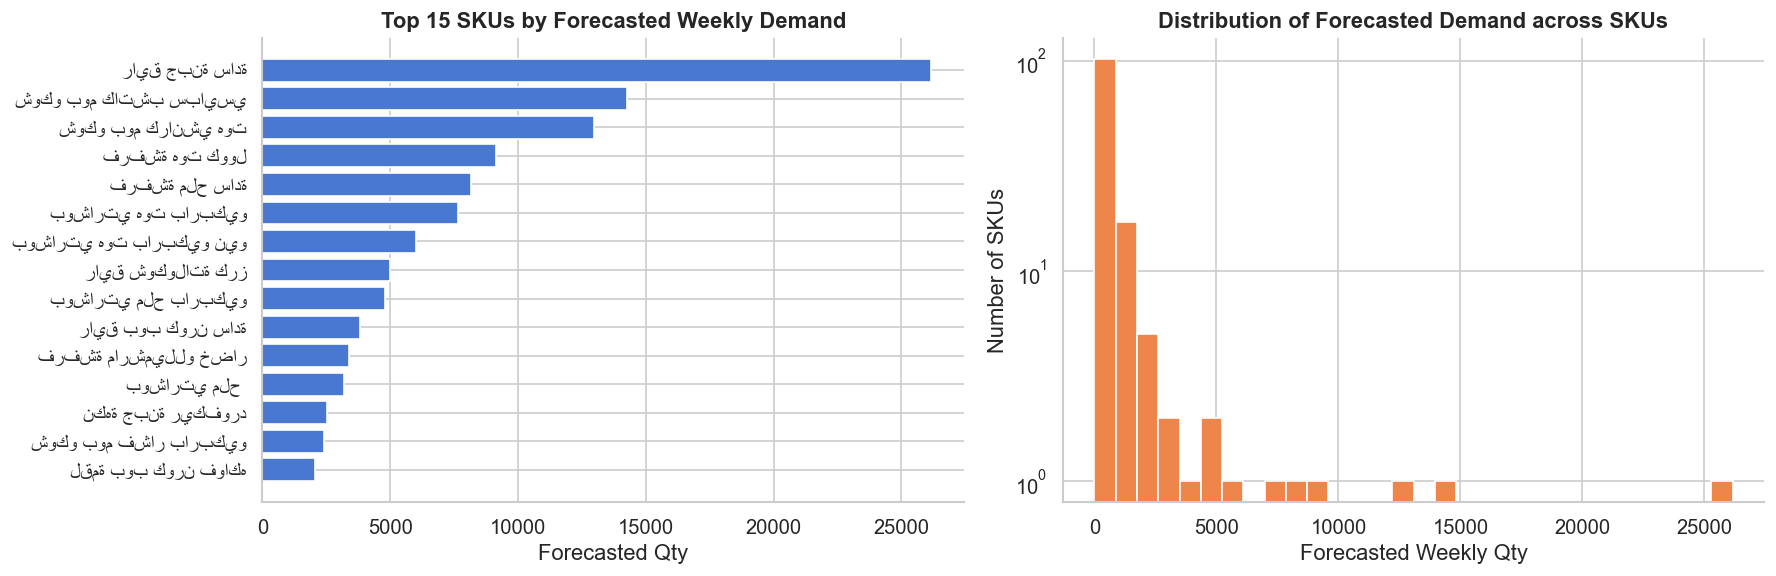

In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# 2.1 Forecast Summary
# ══════════════════════════════════════════════════════════════════════════════
print("📊 Forecast Summary Statistics (Weekly Demand):")
print(df_fc['forecast_mean'].describe().to_string())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Top 15 SKUs by Forecast
top_fc = df_fc.nlargest(15, 'forecast_mean')
axes[0].barh(top_fc['ItemName'], top_fc['forecast_mean'], color=COLORS[0])
axes[0].invert_yaxis()
axes[0].set_title('Top 15 SKUs by Forecasted Weekly Demand', fontweight='bold')
axes[0].set_xlabel('Forecasted Qty')

# Distribution of Forecasts
axes[1].hist(df_fc['forecast_mean'], bins=30, color=COLORS[1], edgecolor='white')
axes[1].set_title('Distribution of Forecasted Demand across SKUs', fontweight='bold')
axes[1].set_xlabel('Forecasted Weekly Qty')
axes[1].set_ylabel('Number of SKUs')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

---
## 3. Inventory Optimization — EOQ <a id='3.-Inventory-Optimization-EOQ'></a>

$$EOQ = \sqrt{\frac{2DS}{H}}$$

- **D** = Annual demand (Forecasted Weekly Mean * 52)
- **S** = Ordering cost per order (Assumed 50 EGP)
- **H** = Holding cost per unit per year (Assumed 20% of Unit Price)

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# 3.1 Calculate EOQ
# ══════════════════════════════════════════════════════════════════════════════
# Assumptions
S = 50.0  # Ordering cost (EGP)
H_RATE = 0.20  # Holding cost rate (20% of item value per year)

df_inv = df_fc.copy()
df_inv['Annual_Demand'] = df_inv['forecast_mean'] * 52
df_inv['Holding_Cost_Unit'] = df_inv['Avg_UnitPrice'] * H_RATE
df_inv['Holding_Cost_Unit'] = df_inv['Holding_Cost_Unit'].replace(0, 0.1) # Avoid division by zero

# EOQ Formula
df_inv['EOQ'] = np.sqrt((2 * df_inv['Annual_Demand'] * S) / df_inv['Holding_Cost_Unit'])
df_inv['Orders_Per_Year'] = df_inv['Annual_Demand'] / df_inv['EOQ']

# Handle edge cases
df_inv['EOQ'] = df_inv['EOQ'].fillna(0).round()
df_inv['Orders_Per_Year'] = df_inv['Orders_Per_Year'].fillna(0).round(1)

top_eoq = df_inv.nlargest(10, 'EOQ')[['ItemName', 'Annual_Demand', 'EOQ', 'Orders_Per_Year', 'Avg_UnitPrice']]
print("📦 Top 10 SKUs by Economic Order Quantity (EOQ):")
print(top_eoq.to_string(index=False))

📦 Top 10 SKUs by Economic Order Quantity (EOQ):
             ItemName  Annual_Demand      EOQ  Orders_Per_Year  Avg_UnitPrice
 شوكو بوم كرانشي سادة   6.585470e+04 234849.0              0.3       0.000597
    جرافيتي مانجو بوب   4.960709e+03  32093.0              0.2       0.002408
       رايق جبنة سادة   1.359920e+06   2191.0            620.7     141.641753
    رايق شوكولاتة كرز   2.600270e+05   1002.0            259.5     129.493322
شوكو بوم كاتشب سبايسي   7.411682e+05    871.0            850.7     488.189378
       فرفشة هوت كوول   4.748685e+05    847.0            560.8     331.094601
  شوكو بوم كرانشي هوت   6.736060e+05    831.0            810.9     488.069363
   رايق بوب كورن سادة   1.988087e+05    827.0            240.4     145.303816
       فرفشة ملح سادة   4.252402e+05    805.0            528.2     328.095098
       نكهة جبنة سوبر   7.605502e+04    551.0            138.0     125.119179


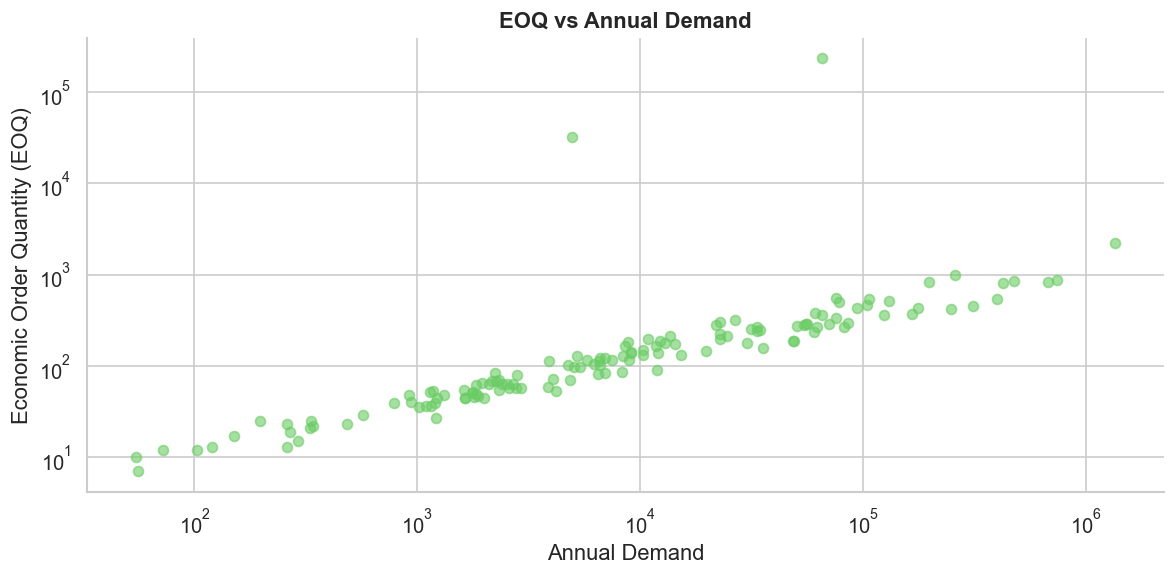

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# 3.2 Visualize EOQ
# ══════════════════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(df_inv['Annual_Demand'], df_inv['EOQ'], alpha=0.6, color=COLORS[2])
ax.set_title('EOQ vs Annual Demand', fontweight='bold')
ax.set_xlabel('Annual Demand')
ax.set_ylabel('Economic Order Quantity (EOQ)')
ax.set_xscale('log')
ax.set_yscale('log')
plt.tight_layout()
plt.show()

---
## 4. Safety Stock & Reorder Point <a id='4.-Safety-Stock-&-Reorder-Point'></a>

$$\text{Safety Stock} = Z \times \sigma_d \times \sqrt{L}$$

$$\text{Reorder Point} = \bar{d} \times L + \text{Safety Stock}$$

Values calculated in M2 using $Z = 1.65$ (95% service level) and $L = 7$ days.

In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# 4.1 Safety Stock & ROP Analysis
# ══════════════════════════════════════════════════════════════════════════════
# Load original metrics to compare
orig_metrics = df_raw.groupby('ItemID').agg(
    orig_ss=('Safety_Stock', 'mean'),
    orig_rop=('ROP', 'mean')
).reset_index()

df_inv = df_inv.merge(orig_metrics, on='ItemID', how='left')

# Highlight differences
df_inv['SS_Diff'] = df_inv['safety_stock_ml'] - df_inv['orig_ss']
df_inv['ROP_Diff'] = df_inv['rop_ml'] - df_inv['orig_rop']

print("🚨 Items requiring highest Safety Stock adjustments vs Original:")
print(df_inv.nlargest(5, 'SS_Diff')[['ItemName', 'orig_ss', 'safety_stock_ml', 'SS_Diff']].to_string(index=False))

🚨 Items requiring highest Safety Stock adjustments vs Original:
             ItemName     orig_ss  safety_stock_ml     SS_Diff
شوكو بوم فشار باربكيو 1159.475630      6792.031727 5632.556097
  شوكو بوم كرانشي هوت 3026.795604      6503.562198 3476.766594
شوكو بوم كاتشب سبايسي 3437.137415      5950.174602 2513.037187
 شوكو بوم كرانشي سادة  461.228571      2841.802398 2380.573827
بوشارتي كرانشي كلاسيك   83.939286      1700.931312 1616.992027


In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# 4.2 Reorder Point Alerts (Simulated)
# ══════════════════════════════════════════════════════════════════════════════
# Simulate current inventory as a random fraction of EOQ + Safety Stock
np.random.seed(42)
df_inv['Current_Inventory'] = (np.random.rand(len(df_inv)) * df_inv['EOQ'] + df_inv['safety_stock_ml']).round()

df_inv['Needs_Reorder'] = df_inv['Current_Inventory'] <= df_inv['rop_ml']

alerts = df_inv[df_inv['Needs_Reorder']][['ItemName', 'Current_Inventory', 'rop_ml', 'EOQ']].sort_values('Current_Inventory')
print(f"⚠️ Alert: {len(alerts)} items need immediate reordering!")
print("-" * 50)
if len(alerts) > 0:
    print(alerts.head(10).to_string(index=False))

⚠️ Alert: 114 items need immediate reordering!
--------------------------------------------------
             ItemName  Current_Inventory     rop_ml  EOQ
 جرافيتي مارشملو ميكس                3.0   3.038469  7.0
       فرفشة ملح سوبر                5.0   8.064027 23.0
   مرشملو هوت باربكيو                6.0   6.774033 25.0
   جرافيتي شوكو كرانش                7.0   7.787464 13.0
  فرفشة بوب كورن كوول               17.0  17.841009 22.0
شوكو بوم كاتشب كلاسيك               18.0  18.746905 25.0
          مرشملو هوت                20.0  49.076509 44.0
       مرشملو توت بري               21.0  51.942549 44.0
  بوكسو بوب كورن سوبر               25.0  47.084319 39.0
   كِسرة شوكولاتة كرز               29.0 107.183756 72.0


---
## 5. Inventory Simulation <a id='5.-Inventory-Simulation'></a>
Simulate 26 weeks of inventory for top SKUs to validate EOQ/ROP policy.

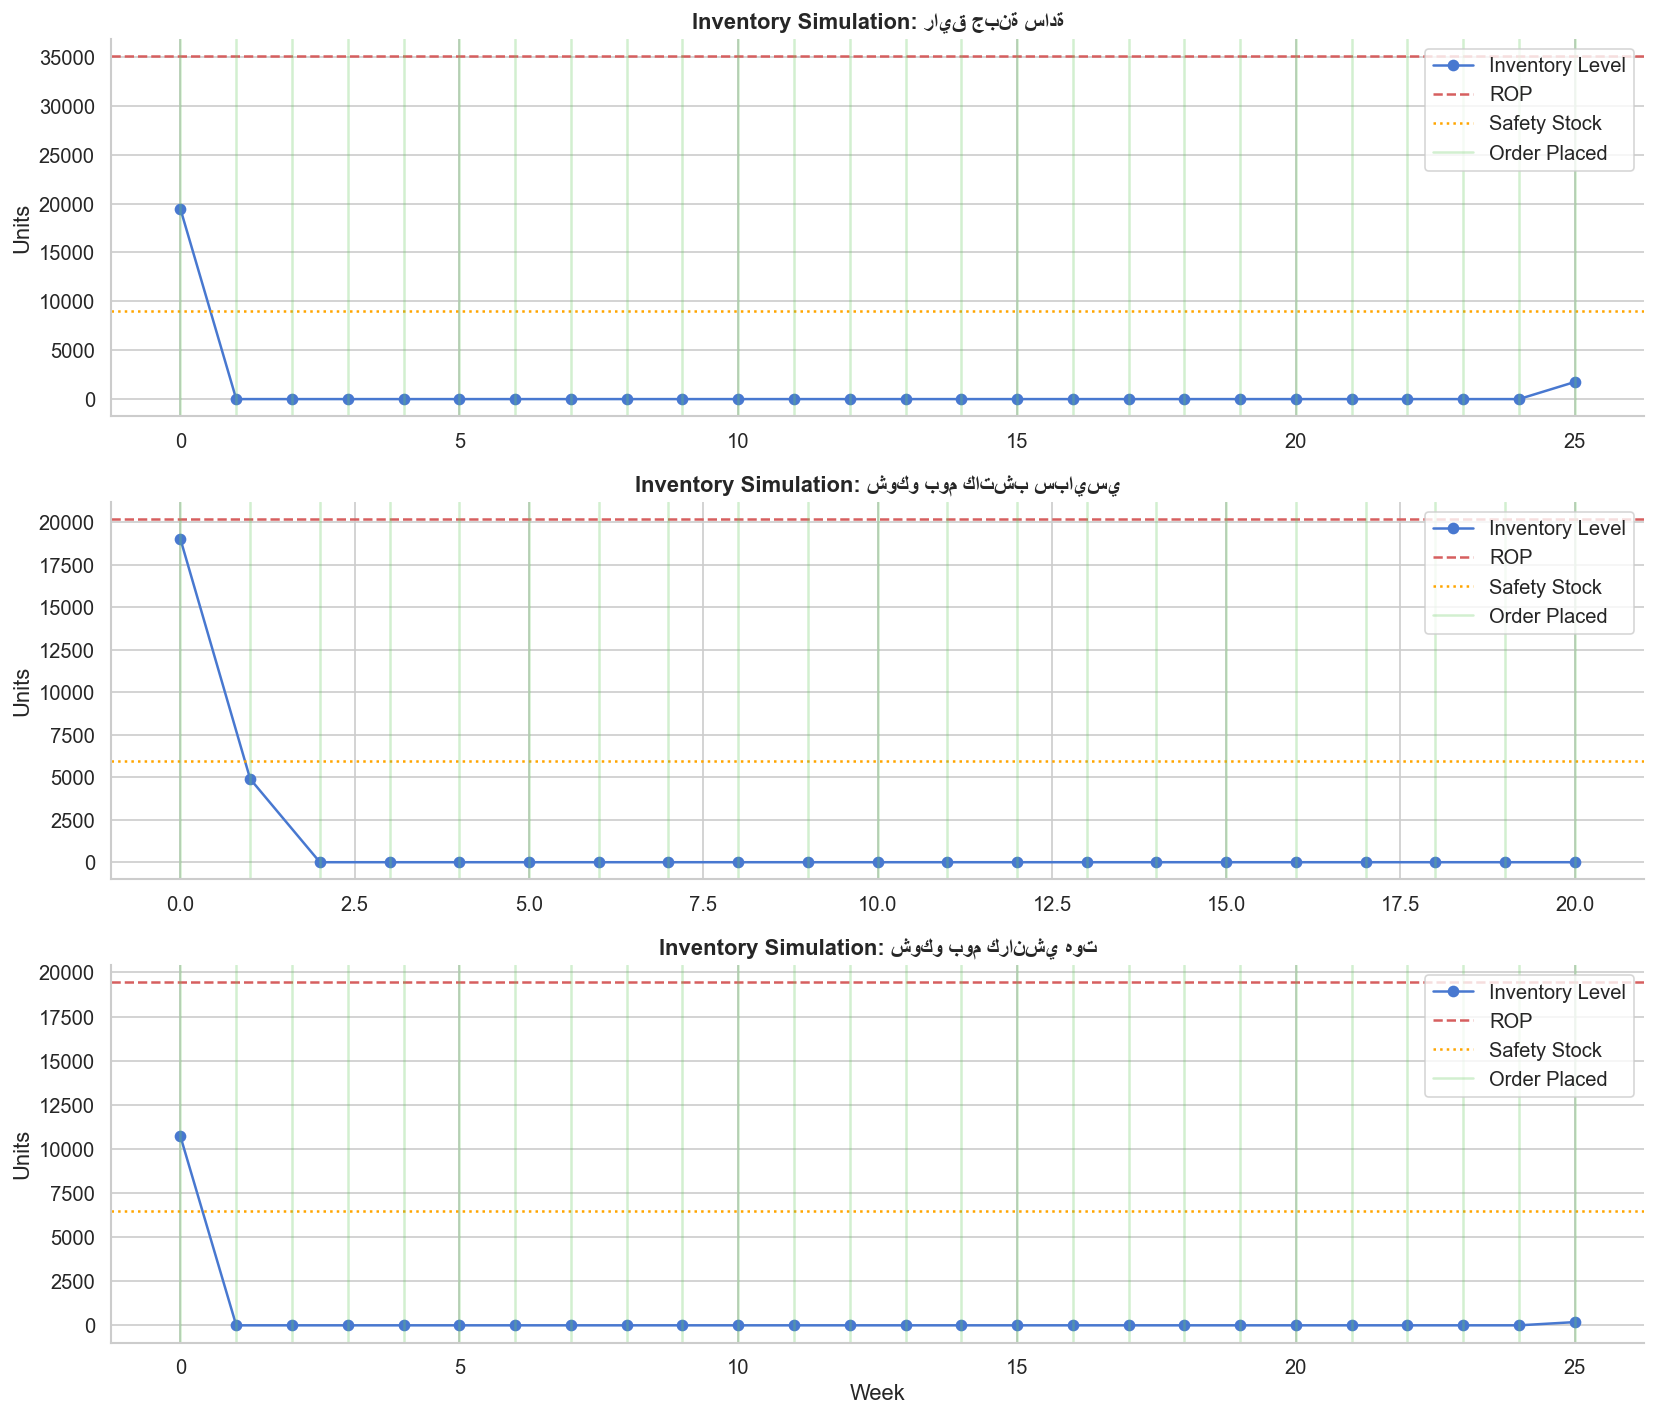

In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# 5.1 Run Simulation
# ══════════════════════════════════════════════════════════════════════════════
# Select top 3 SKUs for simulation
sim_skus = df_inv.nlargest(3, 'forecast_mean')['ItemID'].tolist()

fig, axes = plt.subplots(3, 1, figsize=(14, 12))
weeks = 26

for idx, sku in enumerate(sim_skus):
    sku_data = df_inv[df_inv['ItemID'] == sku].iloc[0]
    hist_data = df_raw[df_raw['ItemID'] == sku].sort_values('Week').reset_index(drop=True)
    
    # We use actual historical demand for the simulation to see how the policy would have performed
    demands = hist_data['Qty'].values[-weeks:] if len(hist_data) >= weeks else hist_data['Qty'].values
    sim_w = len(demands)
    
    inv_levels = []
    inv = sku_data['rop_ml'] + sku_data['EOQ'] # starting inventory
    eoq = sku_data['EOQ']
    rop = sku_data['rop_ml']
    
    orders = []
    stockouts = 0
    
    for w in range(sim_w):
        inv -= demands[w] # fulfill demand
        if inv < 0:
            stockouts += 1
            inv = 0 # lost sales assumption
            
        inv_levels.append(inv)
        
        # Check reorder at end of week
        if inv <= rop:
            inv += eoq # assume 1 week lead time, order arrives start of next week
            orders.append(w)
            
    ax = axes[idx]
    ax.plot(range(sim_w), inv_levels, 'b-', marker='o', label='Inventory Level')
    ax.axhline(rop, color='r', linestyle='--', label='ROP')
    ax.axhline(sku_data['safety_stock_ml'], color='orange', linestyle=':', label='Safety Stock')
    
    for o in orders:
        ax.axvline(o, color='g', alpha=0.3, label='Order Placed' if o == orders[0] else "")
        
    ax.set_title(f"Inventory Simulation: {sku_data['ItemName']}", fontweight='bold')
    ax.set_ylabel('Units')
    if idx == 2: ax.set_xlabel('Week')
    ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

---
## 6. MLOps — Data Drift (PSI) <a id='6.-MLOps-Data-Drift'></a>

| PSI Value | Interpretation |
|---|---|
| PSI < 0.1 | ✅ No significant change |
| 0.1 ≤ PSI < 0.25 | ⚠️ Moderate change |
| PSI ≥ 0.25 | 🚨 Significant change — retrain! |

In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# 6.1 Calculate PSI
# ══════════════════════════════════════════════════════════════════════════════
def calculate_psi(expected, actual, buckettype='bins', buckets=10, axis=0):
    """Calculate the PSI (population stability index) across all variables"""
    def psi(expected_array, actual_array, buckets):
        def scale_range (input, min, max):
            input += -(np.min(input))
            input /= np.max(input) / (max - min)
            input += min
            return input

        breakpoints = np.arange(0, buckets + 1) / (buckets) * 100
        breakpoints = scale_range(breakpoints, np.min(expected_array), np.max(expected_array))
        
        expected_percents = np.histogram(expected_array, breakpoints)[0] / len(expected_array)
        actual_percents = np.histogram(actual_array, breakpoints)[0] / len(actual_array)
        
        def sub_psi(e_perc, a_perc):
            if a_perc == 0: a_perc = 0.0001
            if e_perc == 0: e_perc = 0.0001
            return (e_perc - a_perc) * np.log(e_perc / a_perc)
        
        psi_value = np.sum(sub_psi(expected_percents[i], actual_percents[i]) for i in range(0, len(expected_percents)))
        return psi_value

    if len(expected.shape) == 1:
        psi_values = np.empty(len(expected.shape))
    else:
        psi_values = np.empty(expected.shape[1])

    for i in range(0, len(psi_values)):
        if len(psi_values) == 1:
            psi_values = psi(expected, actual, buckets)
        elif type(expected) == pd.DataFrame:
            psi_values[i] = psi(expected.iloc[:,i], actual.iloc[:,i], buckets)
        else:
            psi_values[i] = psi(expected[:,i], actual[:,i], buckets)
            
    return psi_values

# Ref: Weeks 1-18, Current: Weeks 23-26
ref_df = df_raw[df_raw['Week'] <= 18].copy()
cur_df = df_raw[df_raw['Week'] >= 23].copy()

features_to_monitor = ['Qty', 'Avg_UnitPrice', 'Total_Promo']
psi_results = []

for feat in features_to_monitor:
    ref_vals = ref_df[feat].dropna().values
    cur_vals = cur_df[feat].dropna().values
    
    if len(ref_vals) > 0 and len(cur_vals) > 0:
        psi_val = calculate_psi(ref_vals, cur_vals, buckets=10)
        
        status = "✅ Stable" if psi_val < 0.1 else "⚠️ Moderate Drift" if psi_val < 0.25 else "🚨 Severe Drift"
        psi_results.append({
            'Feature': feat,
            'PSI': round(psi_val, 4),
            'Status': status
        })

psi_df = pd.DataFrame(psi_results)
print("📊 Data Drift (PSI) Results:")
print(psi_df.to_string(index=False))

📊 Data Drift (PSI) Results:
      Feature    PSI   Status
          Qty 0.0337 ✅ Stable
Avg_UnitPrice 0.0776 ✅ Stable
  Total_Promo 0.0216 ✅ Stable


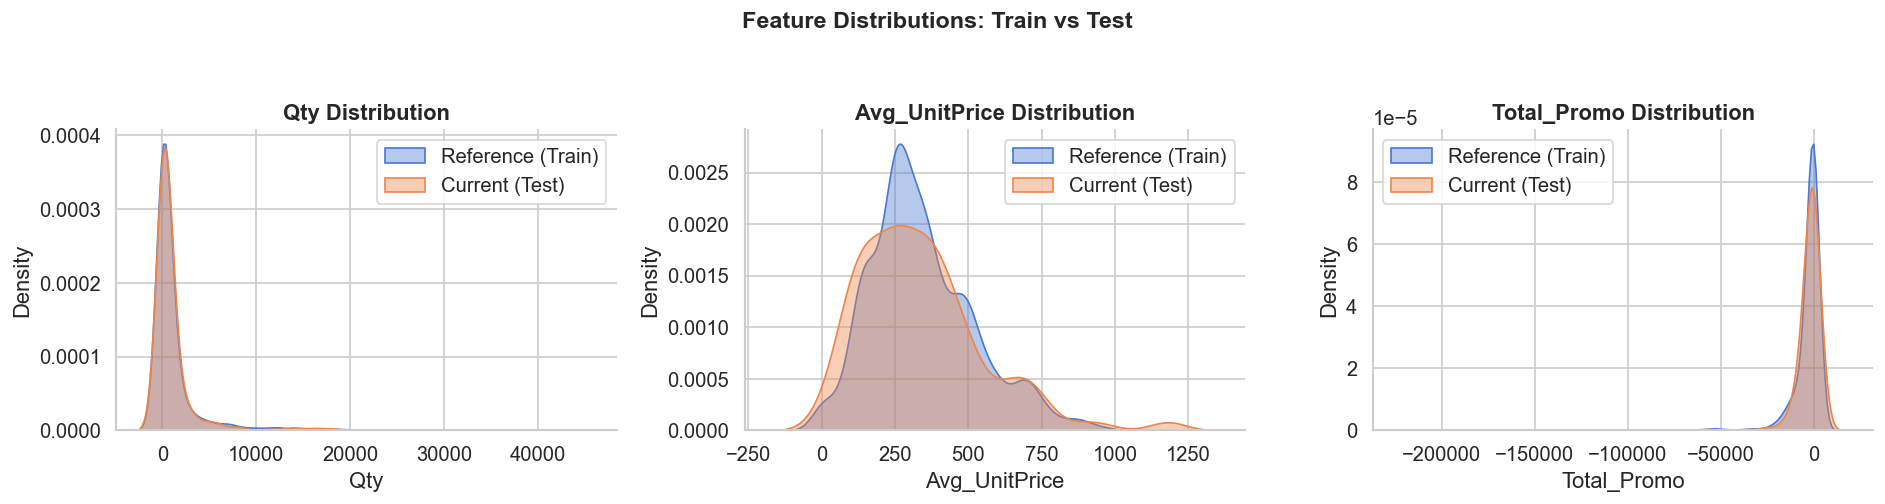

In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# 6.2 Visualize Drift
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, feat in enumerate(features_to_monitor):
    sns.kdeplot(ref_df[feat], ax=axes[i], label='Reference (Train)', fill=True, color=COLORS[0], alpha=0.4)
    sns.kdeplot(cur_df[feat], ax=axes[i], label='Current (Test)', fill=True, color=COLORS[1], alpha=0.4)
    axes[i].set_title(f'{feat} Distribution', fontweight='bold')
    axes[i].legend()

plt.suptitle("Feature Distributions: Train vs Test", y=1.05, fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

---
## 7. MLOps — Model Performance Drift <a id='7.-MLOps-Model-Performance-Drift'></a>

📈 Model Performance Tracking (WMAPE per week):
 Week     WMAPE  SKUs
   23 22.485723   112
   24 30.057567   117
   25 29.137081   116
   26 74.284195   112


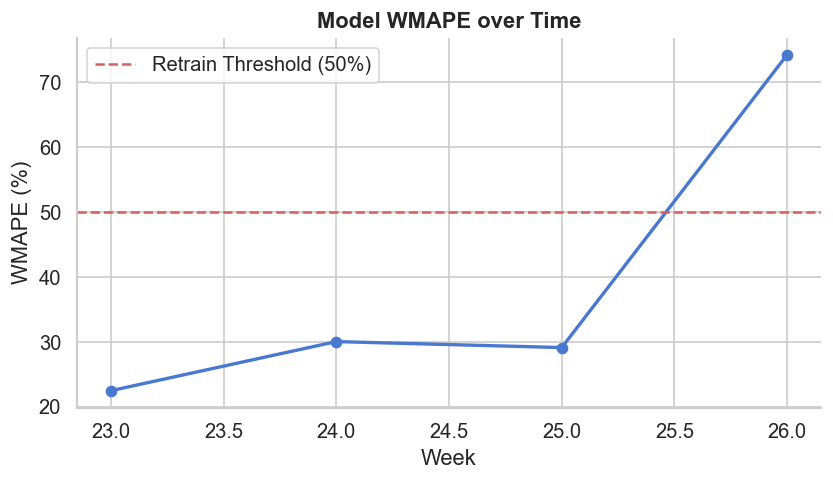

In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# 7.1 Recreate Test Set Performance Tracking
# ══════════════════════════════════════════════════════════════════════════════
# Normally we'd load the model and score on live data. 
# Here we calculate performance per week on the test set to simulate tracking over time.

def wmape(y_true, y_pred):
    m = ~(np.isnan(y_true) | np.isnan(y_pred))
    yt = np.array(y_true)[m]; yp = np.array(y_pred)[m]
    tot = np.sum(yt)
    return np.sum(np.abs(yt - yp)) / tot * 100 if tot > 0 else 0

# We need the ML predictions for the test weeks.
# Let's load the model and encoders from Milestone 2 and score.
MODEL_DIR = Path('..') / 'src' / 'models'

if MODEL_DIR.exists():
    try:
        # Load artifacts
        xgb_model = joblib.load(MODEL_DIR / 'xgb_model.joblib')
        rf_model = joblib.load(MODEL_DIR / 'rf_model.joblib')
        
        with open(MODEL_DIR / 'ensemble_weights.json', 'r') as f:
            weights = json.load(f)
            w_xgb = weights.get('XGBoost', 0.5)
            w_rf = weights.get('Random Forest', 0.5)
            
        with open(MODEL_DIR / 'feature_cols.json', 'r') as f:
            FEATURE_COLS = json.load(f)
            
        with open(MODEL_DIR / 'item_encoder.json', 'r') as f: item_enc = json.load(f)
        with open(MODEL_DIR / 'brand_encoder.json', 'r') as f: brand_enc = json.load(f)
        with open(MODEL_DIR / 'brand_avg_week.json', 'r') as f: brand_avg = json.load(f)
        with open(MODEL_DIR / 'global_mean_qty.json', 'r') as f: gm_qty = json.load(f)['global_mean_qty']

        # Prep global test set identically to M2
        df_test = df_raw[df_raw['Week'] >= 23].copy()
        df_test = df_test[df_test['ItemID'].isin(df_fc['ItemID'])] # only model SKUs
        df_test = df_test.sort_values(['ItemID', 'Week']).reset_index(drop=True)
        
        df_test['Qty_log'] = np.log1p(df_test['Qty'])
        for lag in [1, 2, 4]: df_test[f'lag_{lag}'] = df_test.groupby('ItemID')['Qty_log'].shift(lag).bfill()
        df_test['rolling_mean_4'] = df_test.groupby('ItemID')['Qty_log'].transform(lambda x: x.shift(1).rolling(4, min_periods=1).mean()).bfill()
        df_test['rolling_std_4'] = df_test.groupby('ItemID')['Qty_log'].transform(lambda x: x.shift(1).rolling(4, min_periods=1).std()).fillna(0)
        df_test['rolling_mean_4_raw'] = df_test.groupby('ItemID')['Qty'].transform(lambda x: x.shift(1).rolling(4, min_periods=1).mean()).bfill()
        df_test['price_change_pct'] = df_test.groupby('ItemID')['Avg_UnitPrice'].pct_change().fillna(0).clip(-1, 1)
        df_test['log_price'] = np.log1p(df_test['Avg_UnitPrice'])
        df_test['has_promo'] = (df_test['Total_Promo'] > 0).astype(int)
        df_test['Month'] = pd.to_datetime(df_test['Year'].astype(str)+'-W'+df_test['Week'].astype(str).str.zfill(2)+'-1', format='%G-W%V-%u').dt.month
        df_test['week_sin'] = np.sin(2 * np.pi * df_test['Week'] / 52)
        df_test['week_cos'] = np.cos(2 * np.pi * df_test['Week'] / 52)
        df_test['UOM_encoded'] = (df_test['UOM'] == 'PL').astype(int)
        
        df_test['item_encoded'] = df_test['ItemID'].map(item_enc).fillna(gm_qty)
        df_test['brand_encoded'] = df_test['BrandID'].map(brand_enc).fillna(gm_qty)
        df_test['brand_avg_week_qty'] = df_test['BrandID'].map(brand_avg).fillna(gm_qty)

        X_test = df_test[FEATURE_COLS].fillna(0)
        
        def to_real(log_preds): return np.clip(np.expm1(np.clip(log_preds, 0, None)), 0, None)
        
        preds_xgb = to_real(xgb_model.predict(X_test))
        preds_rf = to_real(rf_model.predict(X_test))
        df_test['pred_ens'] = w_xgb * preds_xgb + w_rf * preds_rf
        
        # Calculate WMAPE per week
        perf_tracking = []
        for w in sorted(df_test['Week'].unique()):
            mask = df_test['Week'] == w
            wmap = wmape(df_test.loc[mask, 'Qty'], df_test.loc[mask, 'pred_ens'])
            perf_tracking.append({'Week': w, 'WMAPE': wmap, 'SKUs': mask.sum()})
            
        perf_df = pd.DataFrame(perf_tracking)
        print("📈 Model Performance Tracking (WMAPE per week):")
        print(perf_df.to_string(index=False))
        
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(perf_df['Week'], perf_df['WMAPE'], 'bo-', linewidth=2)
        ax.axhline(50, color='r', linestyle='--', label='Retrain Threshold (50%)')
        ax.set_title('Model WMAPE over Time', fontweight='bold')
        ax.set_xlabel('Week')
        ax.set_ylabel('WMAPE (%)')
        ax.legend()
        plt.show()

    except Exception as e:
        print(f"Error loading models: {e}. Run Notebook 02 first.")
else:
    print("Model directory not found. Run Notebook 02 first.")

---
## 8. Retraining Decision Logic <a id='8.-Retraining-Decision-Logic'></a>

In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# 8.1 Automated Retraining Check
# ══════════════════════════════════════════════════════════════════════════════
print("🔍 MLOps Automated Health Check")
print("-" * 40)

retrain_recommended = False
reasons = []

# 1. Check Data Drift
severe_drift = psi_df[psi_df['Status'] == '🚨 Severe Drift']
if len(severe_drift) > 0:
    retrain_recommended = True
    reasons.append(f"Severe data drift detected in {len(severe_drift)} features: {', '.join(severe_drift['Feature'].tolist())}")

# 2. Check Model Performance
if 'perf_df' in locals():
    recent_wmape = perf_df['WMAPE'].iloc[-1]
    if recent_wmape > 50.0:
        retrain_recommended = True
        reasons.append(f"Model WMAPE ({recent_wmape:.1f}%) exceeded threshold of 50%")
        
# Final Decision
if retrain_recommended:
    print("🚨 RETRAINING REQUIRED")
    for r in reasons: print(f"  - {r}")
else:
    print("✅ System Healthy. No retraining required.")

🔍 MLOps Automated Health Check
----------------------------------------
🚨 RETRAINING REQUIRED
  - Model WMAPE (74.3%) exceeded threshold of 50%


---
## 9. Summary Report <a id='9.-Summary-Report'></a>

In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# 9.1 Export Consolidated Inventory Report
# ══════════════════════════════════════════════════════════════════════════════
# Final columns
final_cols = ['ItemID', 'ItemName', 'forecast_mean', 'EOQ', 'safety_stock_ml', 'rop_ml', 'Orders_Per_Year']
inv_report = df_inv[final_cols].copy()

# Save
REPORT_PATH = PROC_DIR / 'inventory_report.csv'
inv_report.to_csv(REPORT_PATH, index=False, encoding='utf-8-sig')

print(f"✅ Final Inventory Report saved to: {REPORT_PATH}")
print(f"   Total SKUs analyzed: {len(inv_report)}")
print(f"   Avg EOQ: {inv_report['EOQ'].mean():.1f} units")
print(f"   Items below ROP: {len(alerts)}")

print("\n" + "="*50)
print("🎯 MILESTONE 3 & 4 COMPLETE")
print("="*50)
print("The inventory optimization engine is fully built and monitored.")
print("Proceed to build the FastAPI backend to serve these results.")

✅ Final Inventory Report saved to: ..\data\processed\inventory_report.csv
   Total SKUs analyzed: 136
   Avg EOQ: 2158.1 units
   Items below ROP: 114

🎯 MILESTONE 3 & 4 COMPLETE
The inventory optimization engine is fully built and monitored.
Proceed to build the FastAPI backend to serve these results.
